## Домашнее задание 3

- Считайте датасет из файла [train.csv](https://disk.yandex.ru/i/gSHLosoobj_JsA) (это данные о выживаемости на Титанике) — **1 балл**

- Визуализируйте распределение значений признаков `Survived`, `Pclass`, `Age`, `Sex`, `Parch` — **2 балла**

- Постройте график типа **boxplot** для столбца `Age` — **2 балл**

- Проинтерпретируйте полученный график — **2 балла**

- Постройте график типа **pie chart** для переменных `Survived`, `Pclass`, подпишите доли в процентах — **2 балла**

- Постройте график типа **pairplot** для всех числовых переменных датасета — **2 балла**

- Постройте **violin plot** распределения возраста (`Age`) в зависимости от пола (`Sex`) — **2 балла**

- Постройте **heatmap** корреляционной матрицы числовых признаков — **2 балла**

- Постройте интерактивный **sunburst plot** (plotly):
  - первый уровень — количество пассажиров в каждом классе,
  - второй уровень — количество женщин/мужчин в каждом классе  
  — **3 балла**


- Снабдите все построенные графики наименованиями (`title`), подписями осей и легендами — **2 балла**

- Считайте датасет из файла [train.csv](https://disk.yandex.ru/i/gSHLosoobj_JsA) (это данные о выживаемости на Титанике) — **1 балл**


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#устанавливаем стиль для графиков seaborn
sns.set_theme(style="whitegrid")

df = pd.read_csv('train.csv')

#выведем первые 5 строк, чтобы убедиться в корректности загрузки
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex, Parch — 2 балла

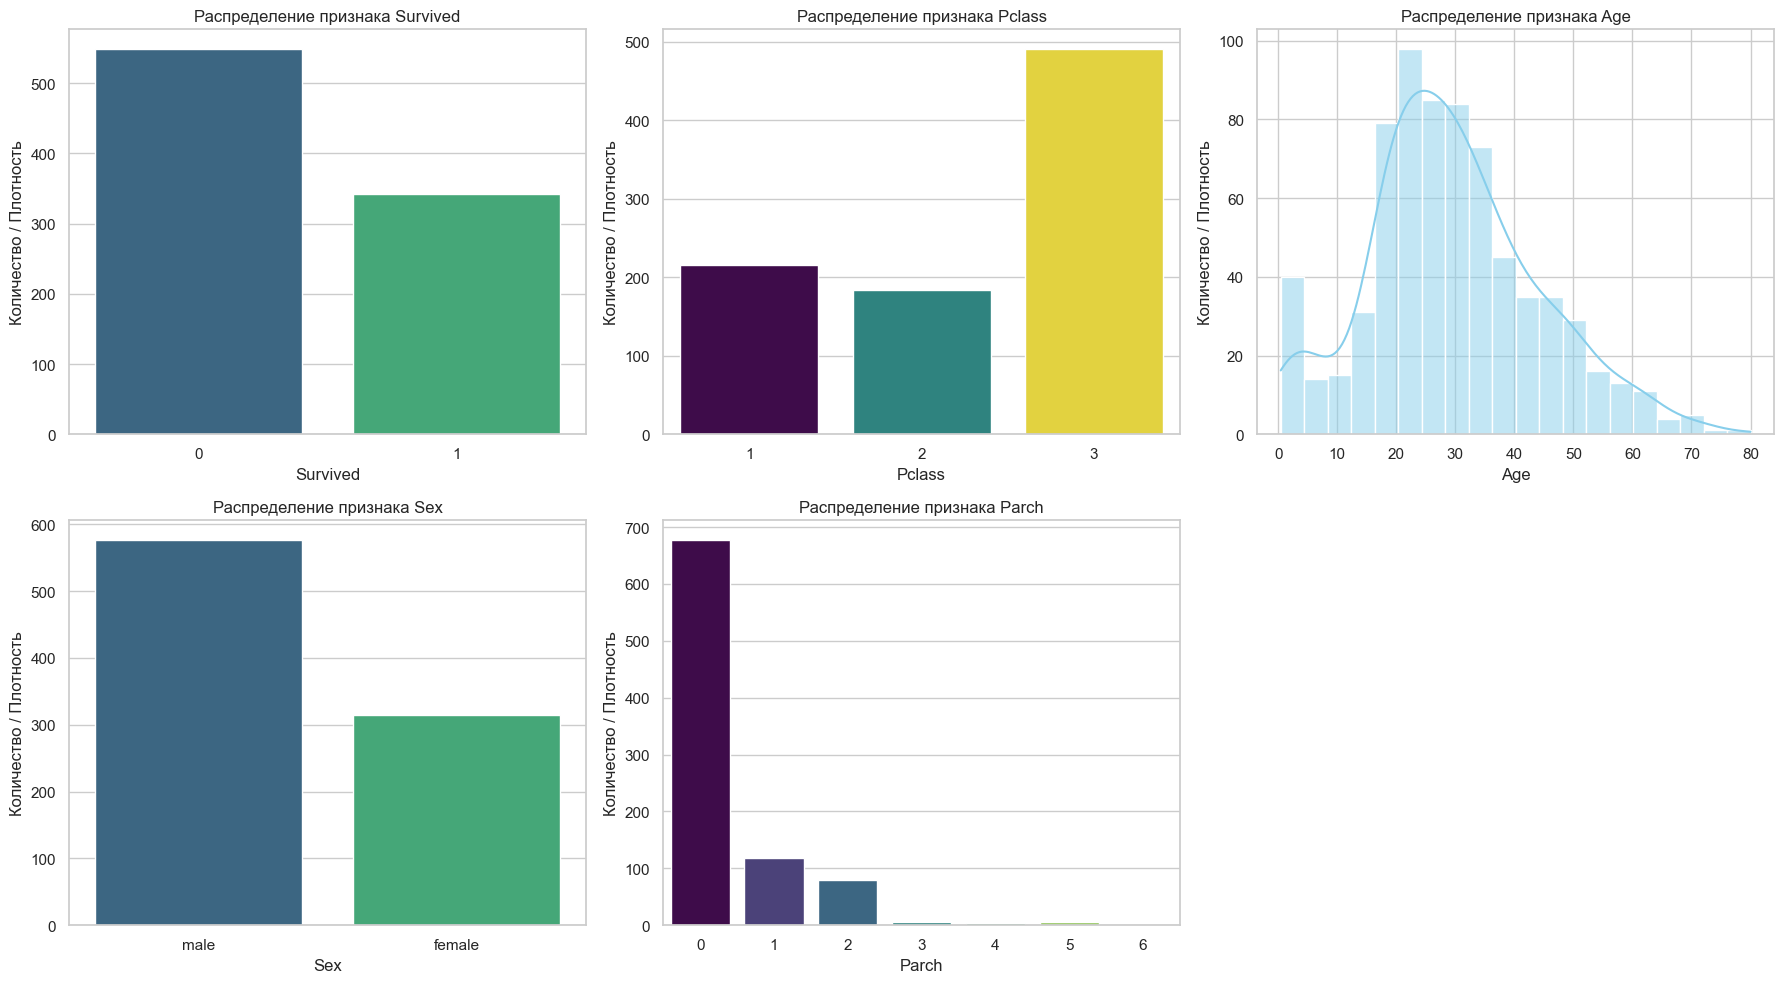

In [10]:
#визуализируем распределение Survived, Pclass, Age, Sex, Parch
features = ['Survived', 'Pclass', 'Age', 'Sex', 'Parch']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    #проверяем, является ли признак категориальным (строка или мало уникальных значений)
    if df[col].dtype == 'object' or df[col].nunique() < 10:
        #для категорий используем countplot
        sns.countplot(data=df, x=col, ax=axes[i], hue=col, palette='viridis', legend=False)
    else:
        #для непрерывных чисел (Age): используем гистограмму
        sns.histplot(data=df, x=col, ax=axes[i], kde=True, color='skyblue')
    
    axes[i].set_title(f'Распределение признака {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество / Плотность')

#удаляем пустой 6-й подграфик
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

- Постройте график типа boxplot для столбца Age — 2 балл

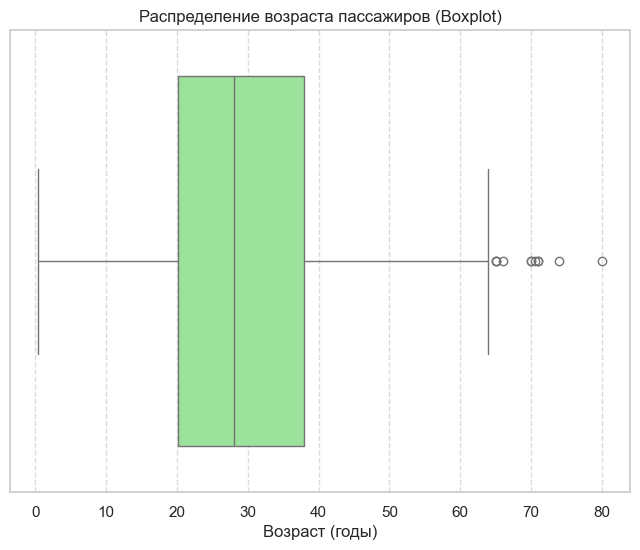

In [14]:
# построение boxplot для столбца Age
plt.figure(figsize=(8, 6))

# берем столбец возраста и окрашиваем его
sns.boxplot(x=df['Age'], color='lightgreen') 
#задаем заголовок
plt.title('Распределение возраста пассажиров (Boxplot)')
plt.xlabel('Возраст (годы)')
plt.grid(axis='x', linestyle='--', alpha=0.7) #добавим сетку для удобства чтения
plt.show()

- Проинтерпретируйте полученный график — 2 балла

Интерпретация графика:

Медианая линия находится внутри "ящика" показывает средний возраст пассажиров, могу предположить, что это примерно 28 лет
Основная масса пассажиров находится в возрасте от 20 до 38 лет.
Точки выше верхней "усика" указывают на наличие пожилых пассажиров (старше 65 лет), чей возраст значительно превышает типичные значения для данной выборки. Это выбросы. Ящик смещен чуть ниже центра, что говорит о преобладании молодых людей на борту.

- Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах — 2 балла

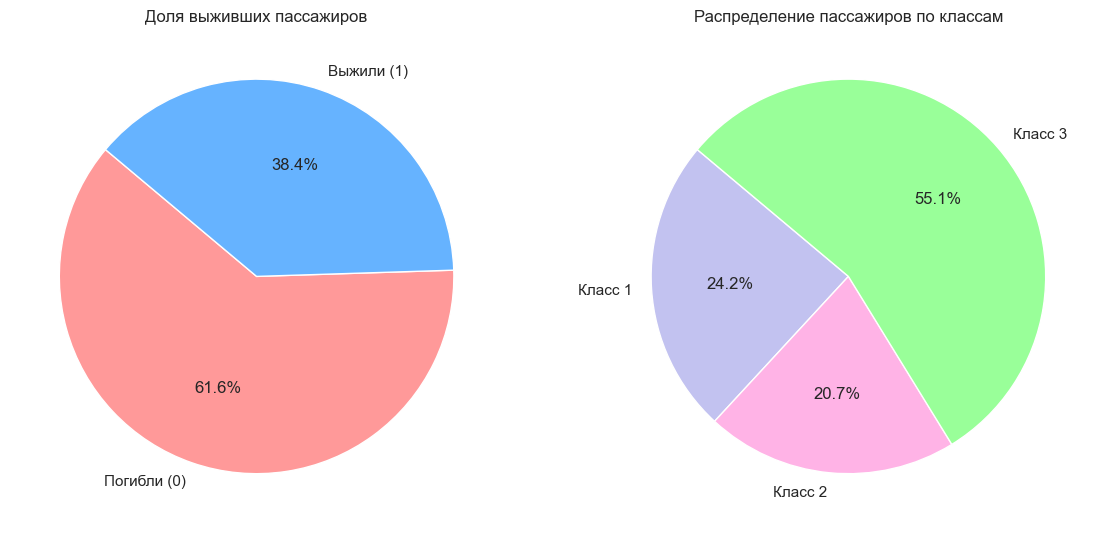

In [17]:
#построение pie chart для "Survived" и "Pclass"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

#данные для выживаемости
survived_counts = df['Survived'].value_counts() 
#разворачивает диаграмму на 140 градусов,для красоты и удобства
ax1.pie(survived_counts, labels=['Погибли (0)', 'Выжили (1)'], autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff']) #обозначаем лейблы (категории), цвета
ax1.set_title('Доля выживших пассажиров')

#данные для классов кают
pclass_counts = df['Pclass'].value_counts().sort_index() 
#мы добавляем сортировку, чтобы классы на графике шли по порядку: 1, 2, 3
ax2.pie(pclass_counts, labels=[f'Класс {i}' for i in pclass_counts.index], autopct='%1.1f%%', startangle=140, colors=['#c2c2f0','#ffb3e6','#99ff99']) #обозначаем лейблы (категории), цвета
ax2.set_title('Распределение пассажиров по классам')

plt.show()

- Постройте график типа **pairplot** для всех числовых переменных датасета — **2 балла**


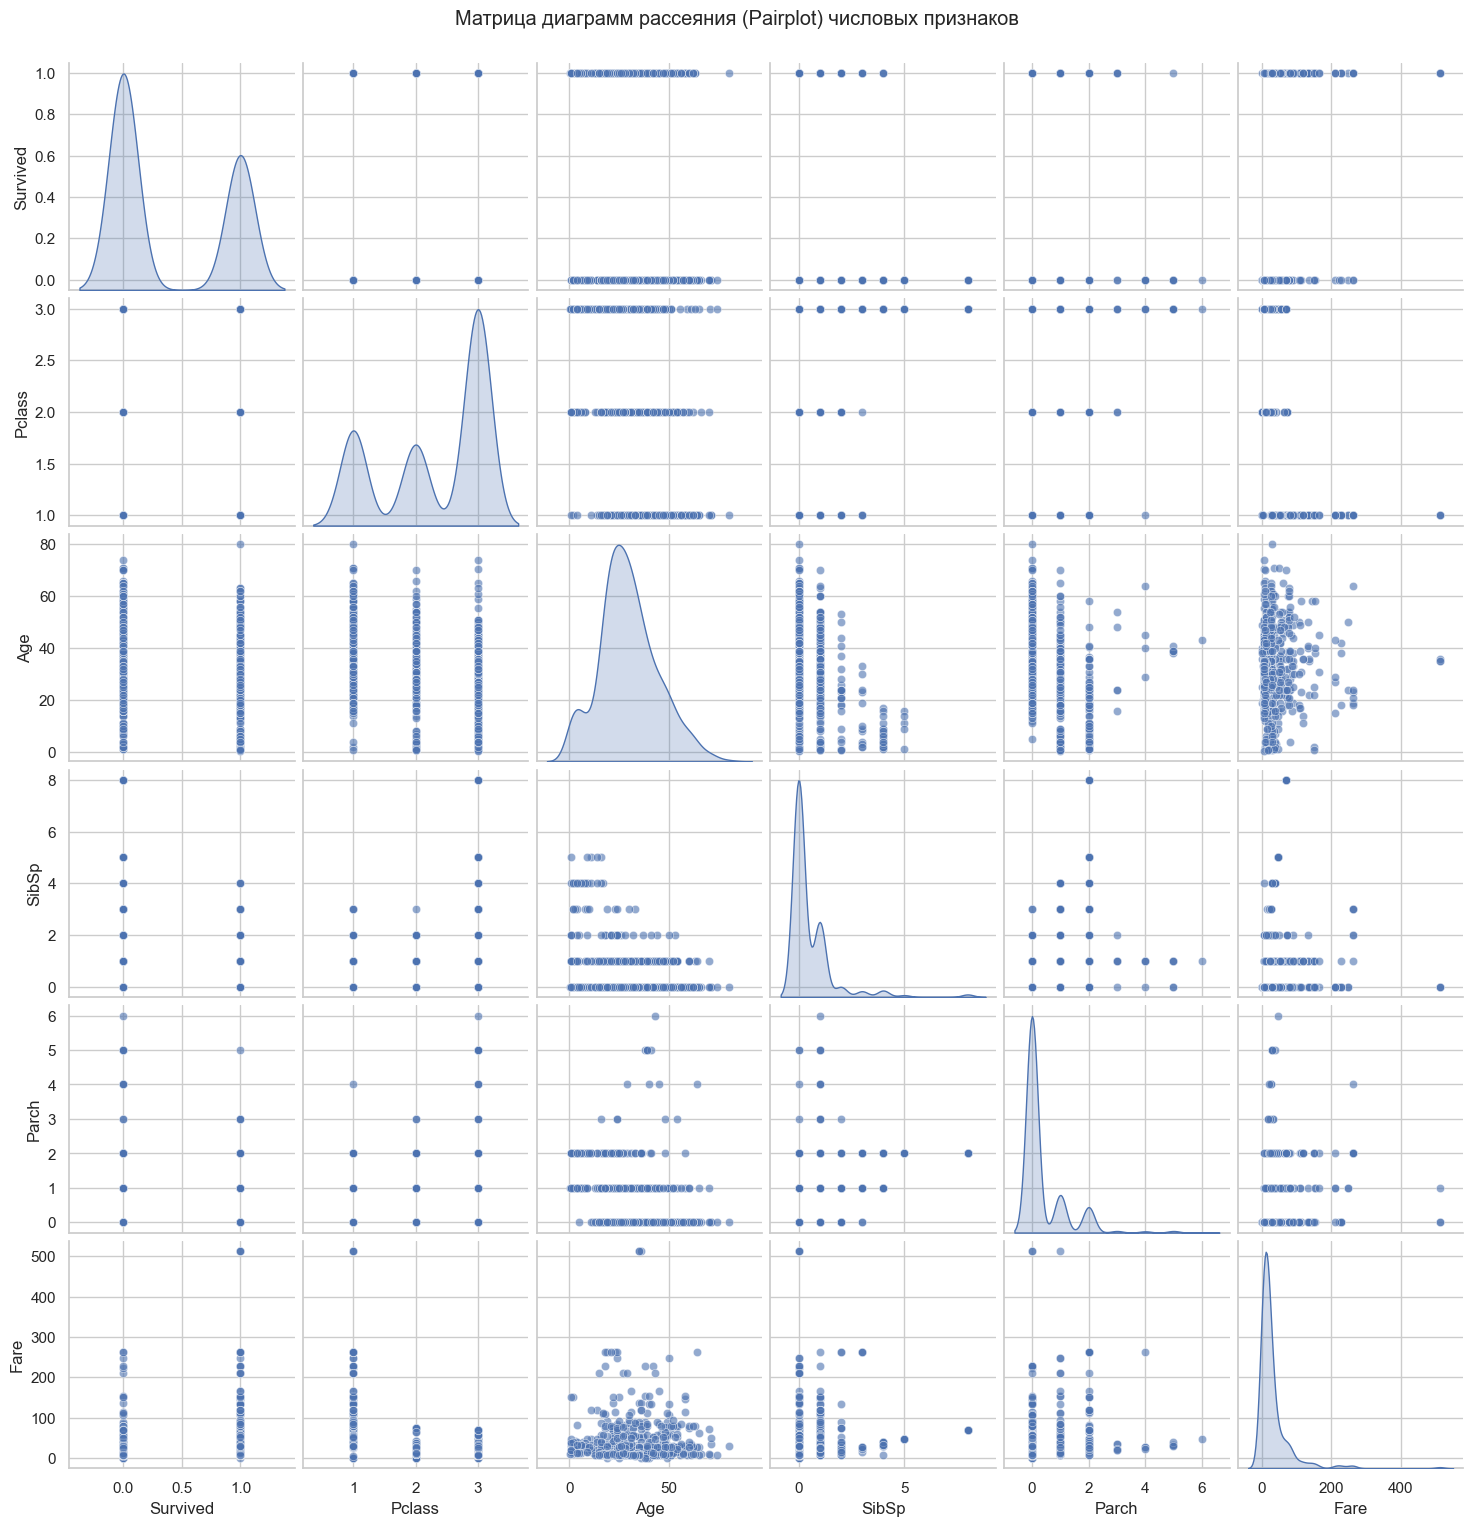

In [26]:
#pairplot для всех числовых переменных
#Выбираем только числовые столбцы и убираем ID, чтобы не засорять график
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['PassengerId'])
sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Матрица диаграмм рассеяния (Pairplot) числовых признаков', y=1.02)
plt.show()

- Постройте **violin plot** распределения возраста (`Age`) в зависимости от пола (`Sex`) — **2 балла**


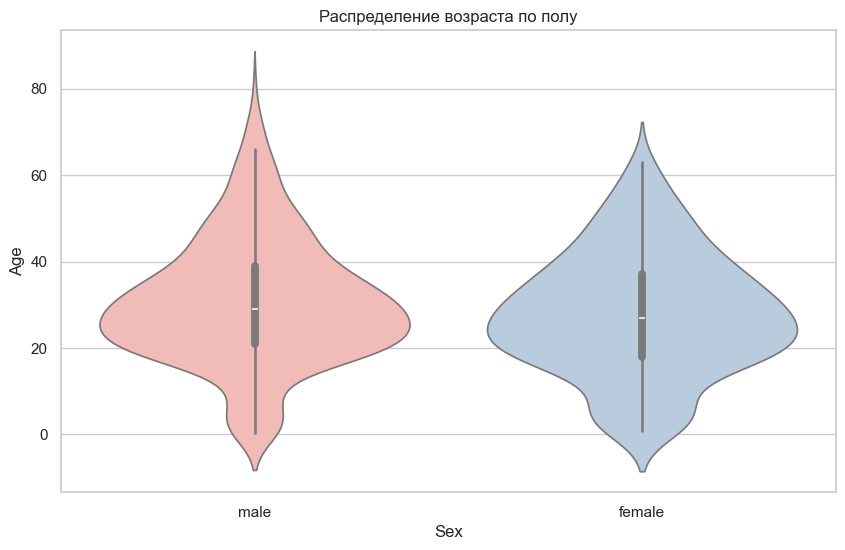

In [27]:
#violin plot распределения возраста в зависимости от пола
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Sex', y='Age', hue='Sex', palette='Pastel1', legend=False)
plt.title('Распределение возраста по полу')
plt.show()

- Постройте **heatmap** корреляционной матрицы числовых признаков — **2 балла**


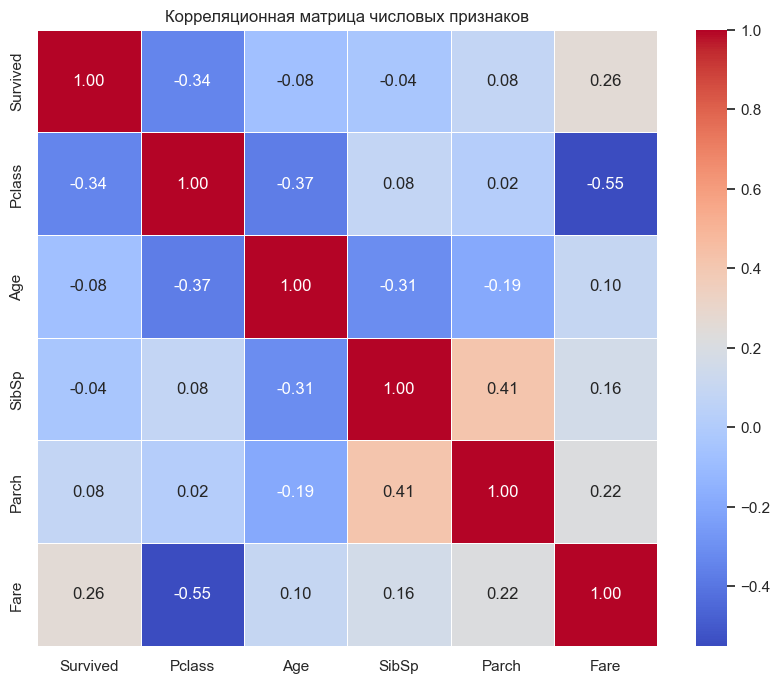

In [28]:
#heatmap корреляционной матрицы
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

- Постройте интерактивный **sunburst plot** (plotly):
  - первый уровень — количество пассажиров в каждом классе,
  - второй уровень — количество женщин/мужчин в каждом классе  
  — **3 балла**


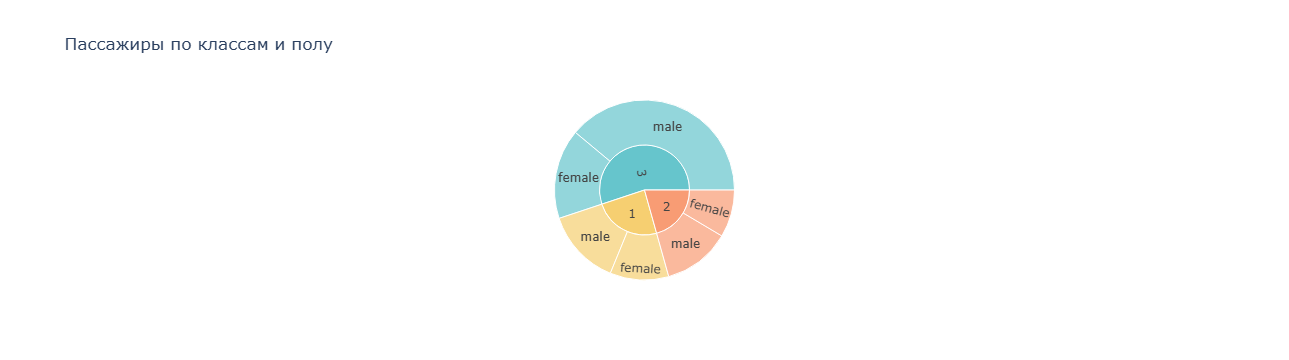

In [29]:
#интерактивный sunburst plot
sun_df = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
fig = px.sunburst(sun_df, path=['Pclass', 'Sex'], values='count', 
                  title='Пассажиры по классам и полу',
                  color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

- Снабдите все построенные графики наименованиями (`title`), подписями осей и легендами — **2 балла**